In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re
from tqdm.auto import tqdm


### Note: rooms run with reverb! Room used in test is anechoic simulation of MIT 46-1004

In [9]:
results_dir = Path('final_results_dir')
results_dir.mkdir(parents=True, exist_ok=True)

In [10]:
all_conditions = pd.read_pickle("binaural_test_manifests/all_target_distractor_pairs.pkl")

In [11]:
len(all_conditions)

63504

In [12]:
ls binaural_eval/simulate_all_target_distractor_location_pairs/

word_task_v10_main_feature_gain_config/


In [13]:
results_dir = Path('binaural_eval/simulate_all_target_distractor_location_pairs/')
model = 'word_task_v10_main_feature_gain_config'

output_paths = list((results_dir / model).glob("*.pkl"))
len(output_paths)

63469

In [ ]:
remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 


In [ ]:
# from concurrent.futures import ThreadPoolExecutor
from multiprocessing import Pool, cpu_count

from functools import partial

results_dir = Path('binaural_eval/simulate_all_target_distractor_location_pairs/')
model = 'word_task_v10_main_feature_gain_config'

output_paths = list((results_dir / model).glob("*.pkl"))



def process_path(path):
    stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')
    remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 
    word_class_map = pickle.load(open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb"))
    ix_to_word = {v: k for k, v in word_class_map.items()}
    gend_map = {True: 'Same sex', False: 'Different sex'}
    model_name_dict = {'word_task_v10_main_feature_gain_config': "Feature-gain Model"}

    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    df['model'] = path.parent.stem
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df.loc[df.index.values, ['word', 'distractor_word', 'sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word', 'sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    df['confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr
    df["target_azim_raw"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim_raw"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # map azim to 0-180
    df['target_azim'] = df['target_azim_raw'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim_raw'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)

    summary_df = df.groupby(['target_azim', 'target_elev', 'distractor_azim', 'distractor_elev', 'snr', 'model']).agg({'accuracy': ['mean', 'sem'],
                                                                                                                       'confusions': ['mean', 'sem']}).reset_index()
    summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
    # remove trailing underscore
    summary_df.columns = [col[:-1] if col[-1] == '_' else col for col in summary_df.columns.values]

    summary_df.rename(columns={"accuracy_mean": "accuracy", "accuracy_sem": "accuracy_sem"}, inplace=True)
    summary_df.rename(columns={"confusions_mean": "confusions", "confusions_sem": "confusions_sem"}, inplace=True)

    return summary_df

with Pool(processes=cpu_count()) as pool:
    process_func = partial(process_path)
    results_dfs = list(tqdm(pool.imap(process_func, output_paths), total=len(output_paths)))

results = pd.concat(results_dfs)

  0%|          | 0/63038 [00:00<?, ?it/s]

In [ ]:
n_unique_elevations = results.target_elev.nunique()
n_unique_azimuths = results.target_azim.nunique()


In [ ]:
from tqdm.auto import tqdm

run_coords = set(
    zip(
        results['target_azim'], results['target_elev'],
        results['distractor_azim'], results['distractor_elev']
    )
)

# Find indices in the dictionary not present in the DataFrame
missing_ixs = []
for ix, items in all_conditions.items():
    target = items['target_loc']
    distractor = items['distract_loc']
    if (remap_azim(target[0]), target[1], remap_azim(distractor[0]), distractor[1]) not in run_coords:
        missing_ixs.append(ix)
len(missing_ixs)

466

In [ ]:
results[(results['target_azim'] == 0) & (results['target_elev'] == -20) & (results['distractor_azim'] == 10) & (results['distractor_elev'] == 0)]

,target_azim,target_elev,distractor_azim,distractor_elev,snr,model,accuracy,accuracy_sem,confusions,confusions_sem
0,0,-20,10,0,0,word_task_v10_main_feature_gain_config,0.725922,0.010098,0.003074,0.001253


## Confusion matrices 

### Plot target x distractor azimuth at all elevations 

/tmp/ipykernel_1689416/3983672199.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbars


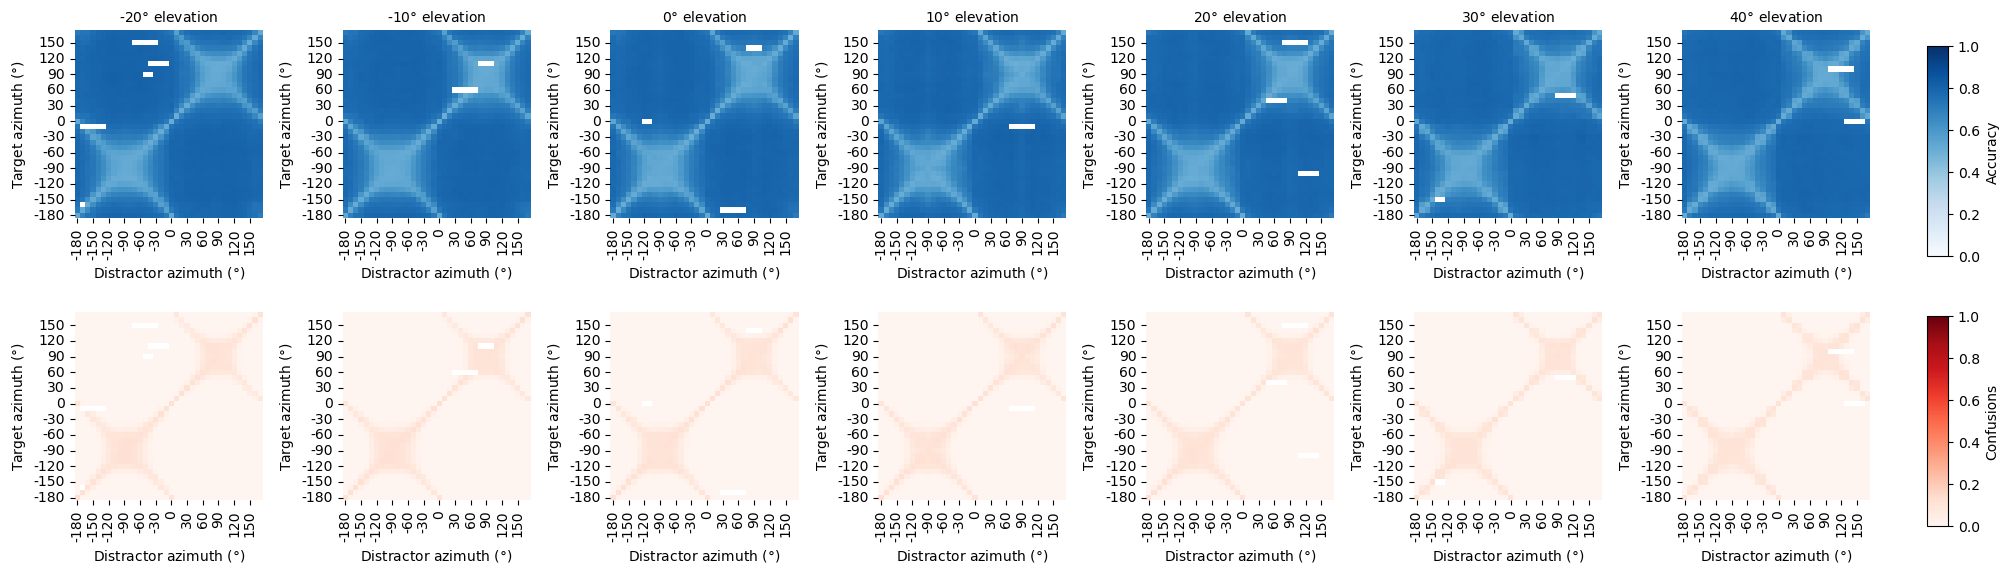

In [ ]:
n_rows = 2  # top row will be accuracy, bottom row will be confusions
n_cols = n_unique_elevations  # number of unique elevations

aspect = 3
fontsize = 10

figsize = (n_cols * aspect, n_rows * aspect)
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=False, sharey=False)

# Create lists to store the heatmaps for adding colorbars later
acc_heatmaps = []
conf_heatmaps = []

for i, elev in enumerate(sorted(results.target_elev.unique())):
    # Get performance where sources are co-located in elevation
    elev_df = results[(results.target_elev == elev) & (results.distractor_elev == elev)]

    acc_to_plot = elev_df.groupby(['target_azim', "distractor_azim"])['accuracy'].mean().unstack()
    acc_heatmap = sns.heatmap(acc_to_plot, vmin=0, vmax=1, cmap='Blues', cbar=False, ax=axes[0, i], square=True, robust=True)
    acc_heatmaps.append(acc_heatmap)

    conf_to_plot = elev_df.groupby(['target_azim', "distractor_azim"])['confusions'].mean().unstack()
    conf_heatmap = sns.heatmap(conf_to_plot, vmin=0, vmax=1, cmap='Reds', cbar=False, ax=axes[1, i], square=True, robust=True)
    conf_heatmaps.append(conf_heatmap)

    axes[0, i].set_title(f"{elev}$\degree$ elevation", fontsize=fontsize)

# Add common colorbars for each row
cbar_ax_acc = fig.add_axes([0.92, 0.55, 0.01, 0.35])  # [left, bottom, width, height]
cbar_ax_conf = fig.add_axes([0.92, 0.1, 0.01, 0.35])  # [left, bottom, width, height]

plt.colorbar(acc_heatmaps[0].get_children()[0], cax=cbar_ax_acc, label="Accuracy")
plt.colorbar(conf_heatmaps[0].get_children()[0], cax=cbar_ax_conf, label="Confusions")

for ax in axes.ravel():
    # set xticks and yticks to range from -180 to 180
    # ax.set_xticks(np.arange(-180, 181, 10))
    # ax.set_yticks(np.arange(-180, 181, 10))
    # ax.set_xticklabels(np.arange(-180, 181, 30), fontsize=fontsize)
    # ax.set_yticklabels(np.arange(-180, 181, 30), fontsize=fontsize)
    # ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.set_xlabel('Distractor azimuth ($\degree$)', fontsize=fontsize)
    ax.set_ylabel('Target azimuth ($\degree$)', fontsize=fontsize)
    ax.invert_yaxis()
    ax.set_aspect('equal')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbars

## Plot the azimuth results

Will plot accuracy and confusions as separate figures

### Accuracy

/tmp/ipykernel_1689416/3739153637.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbars


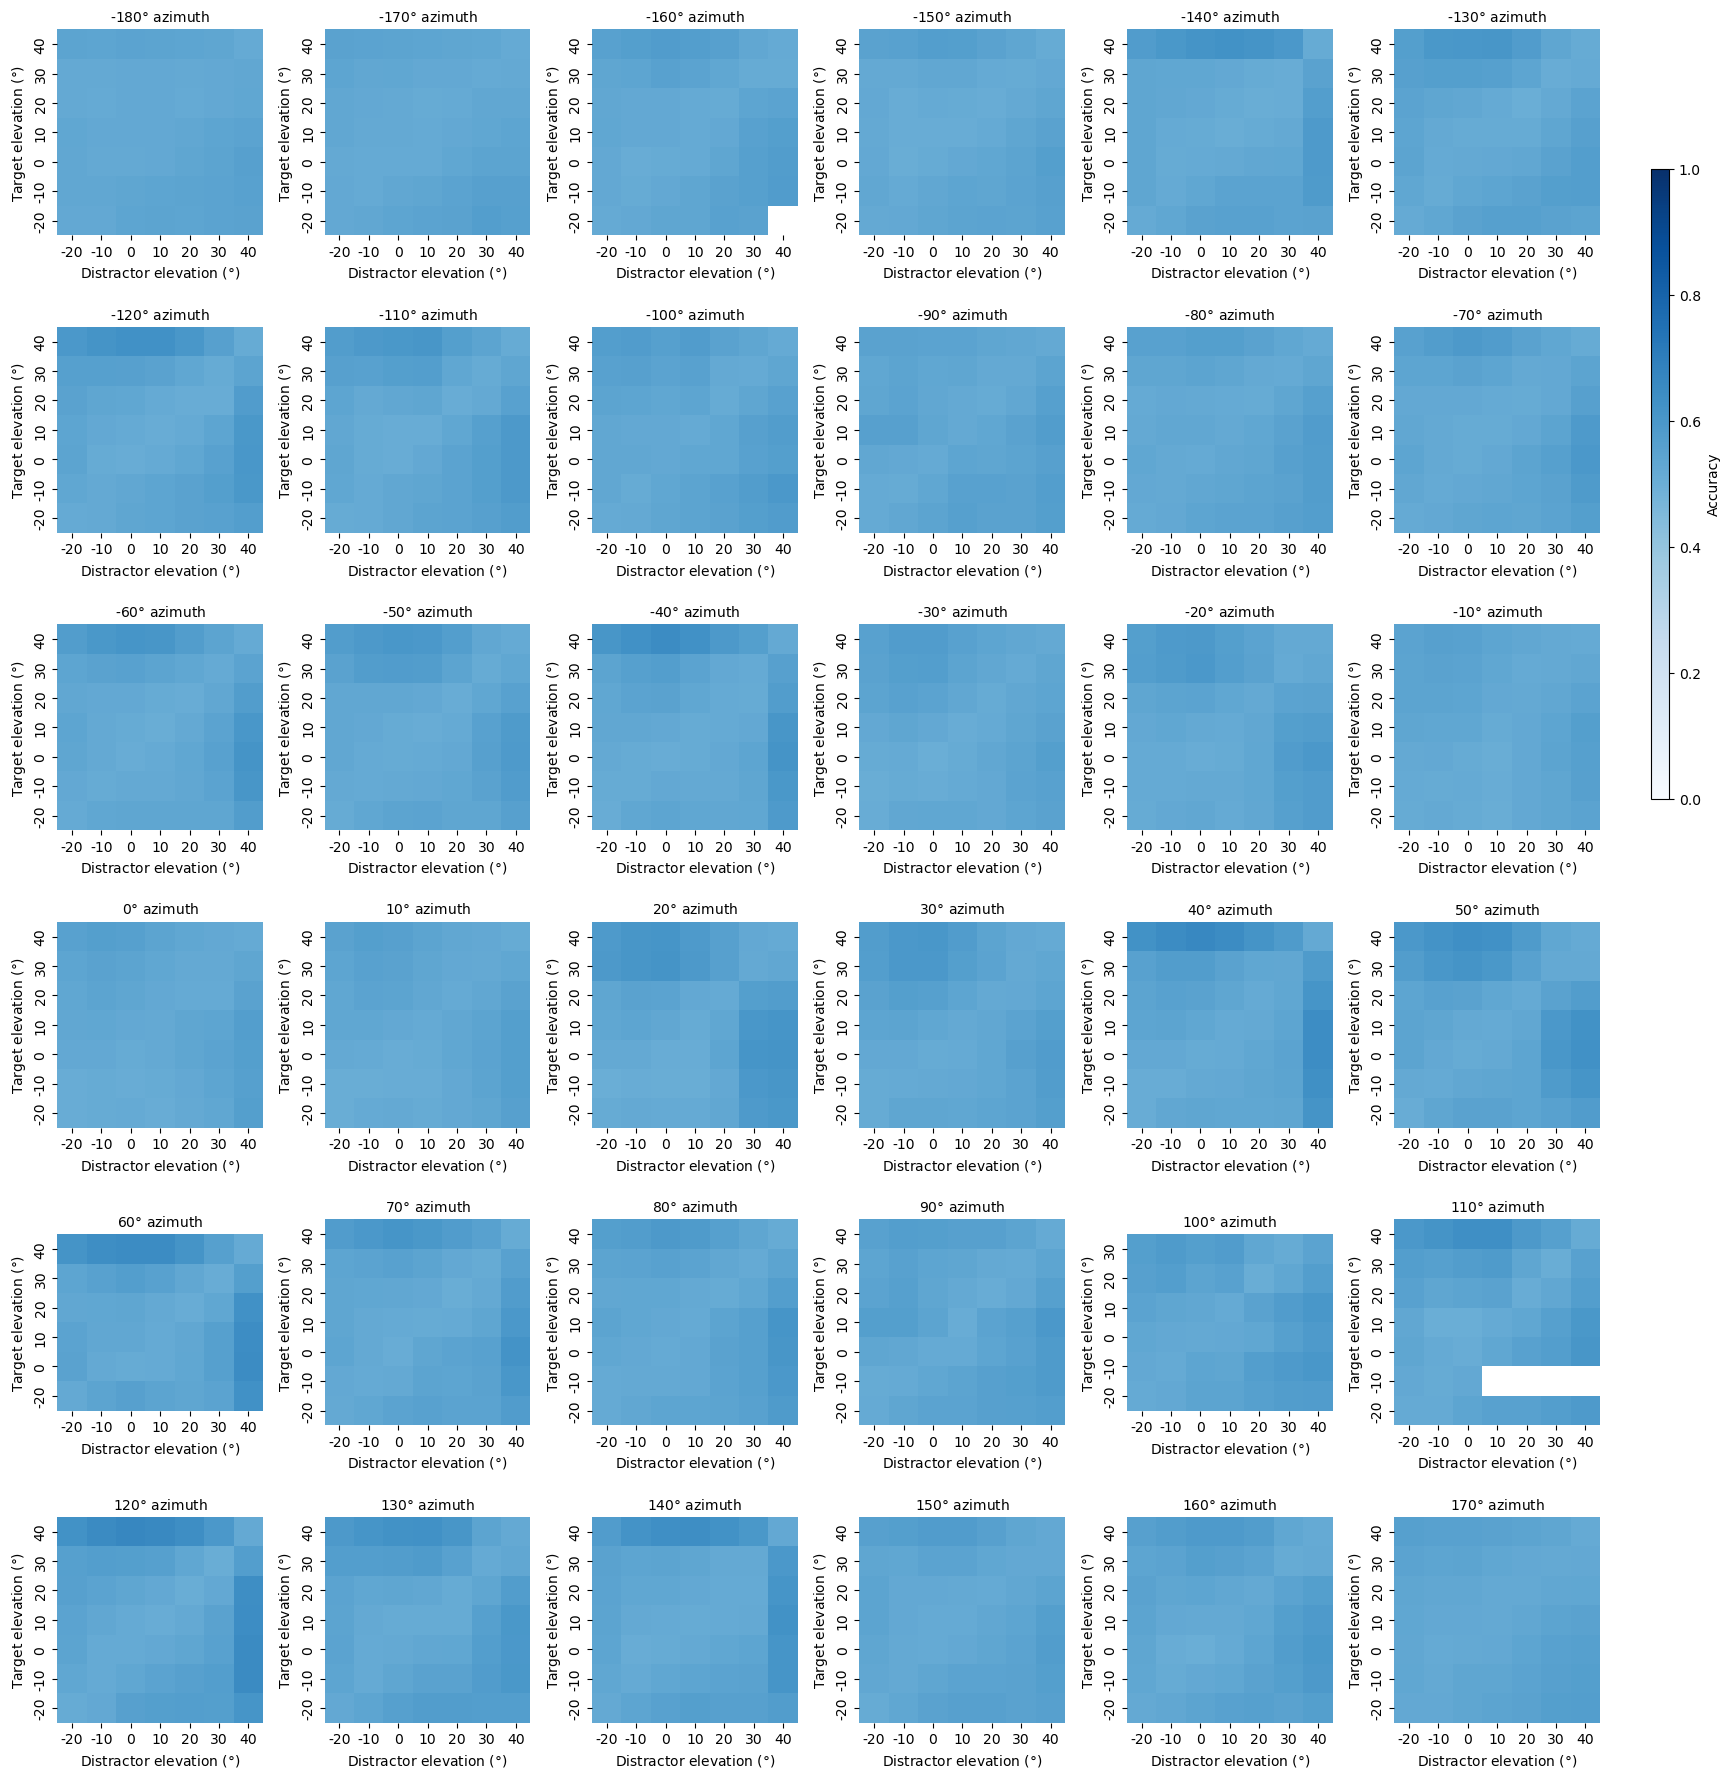

In [ ]:
n_azims = n_unique_azimuths  # number of unique azimuths
n_cols = 6 
n_rows = n_azims // n_cols + (n_azims % n_cols > 0)  # number of rows needed to fit all azimuths

aspect = 3
fontsize = 10

figsize = (n_cols * aspect, n_rows * aspect)
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=False, sharey=False)
axes = axes.flatten()
# Create lists to store the heatmaps for adding colorbars later
acc_heatmaps = []
conf_heatmaps = []

for i, azim in enumerate(sorted(results.target_azim.unique())):
    # Get performance where sources are co-located in elevation
    azim_df = results[(results.target_azim == azim) & (results.distractor_azim == azim)]

    acc_to_plot = azim_df.groupby(['target_elev', "distractor_elev"])['accuracy'].mean().unstack()
    acc_heatmap = sns.heatmap(acc_to_plot, vmin=0, vmax=1, cmap='Blues', cbar=False, ax=axes[i], square=True, robust=True)
    acc_heatmaps.append(acc_heatmap)

    # conf_to_plot = elev_df.groupby(['target_azim', "distractor_azim"])['confusions'].mean().unstack()
    # conf_heatmap = sns.heatmap(conf_to_plot, vmin=0, vmax=1, cmap='Reds', cbar=False, ax=axes[1, i], square=True, robust=True)
    # conf_heatmaps.append(conf_heatmap)

    axes[i].set_title(f"{azim}$\degree$ azimuth", fontsize=fontsize)
    

# Add common colorbars for each row
cbar_ax_acc = fig.add_axes([0.92, 0.55, 0.01, 0.35])  # [left, bottom, width, height]
# cbar_ax_conf = fig.add_axes([0.92, 0.1, 0.01, 0.35])  # [left, bottom, width, height]

plt.colorbar(acc_heatmaps[0].get_children()[0], cax=cbar_ax_acc, label="Accuracy")
# plt.colorbar(conf_heatmaps[0].get_children()[0], cax=cbar_ax_conf, label="Confusions")

for ax in axes.ravel():
    ax.set_xlabel('Distractor elevation ($\degree$)', fontsize=fontsize)
    ax.set_ylabel('Target elevation ($\degree$)', fontsize=fontsize)
    ax.invert_yaxis()
    ax.set_aspect('equal')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbars

/tmp/ipykernel_1689416/3551811629.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbars


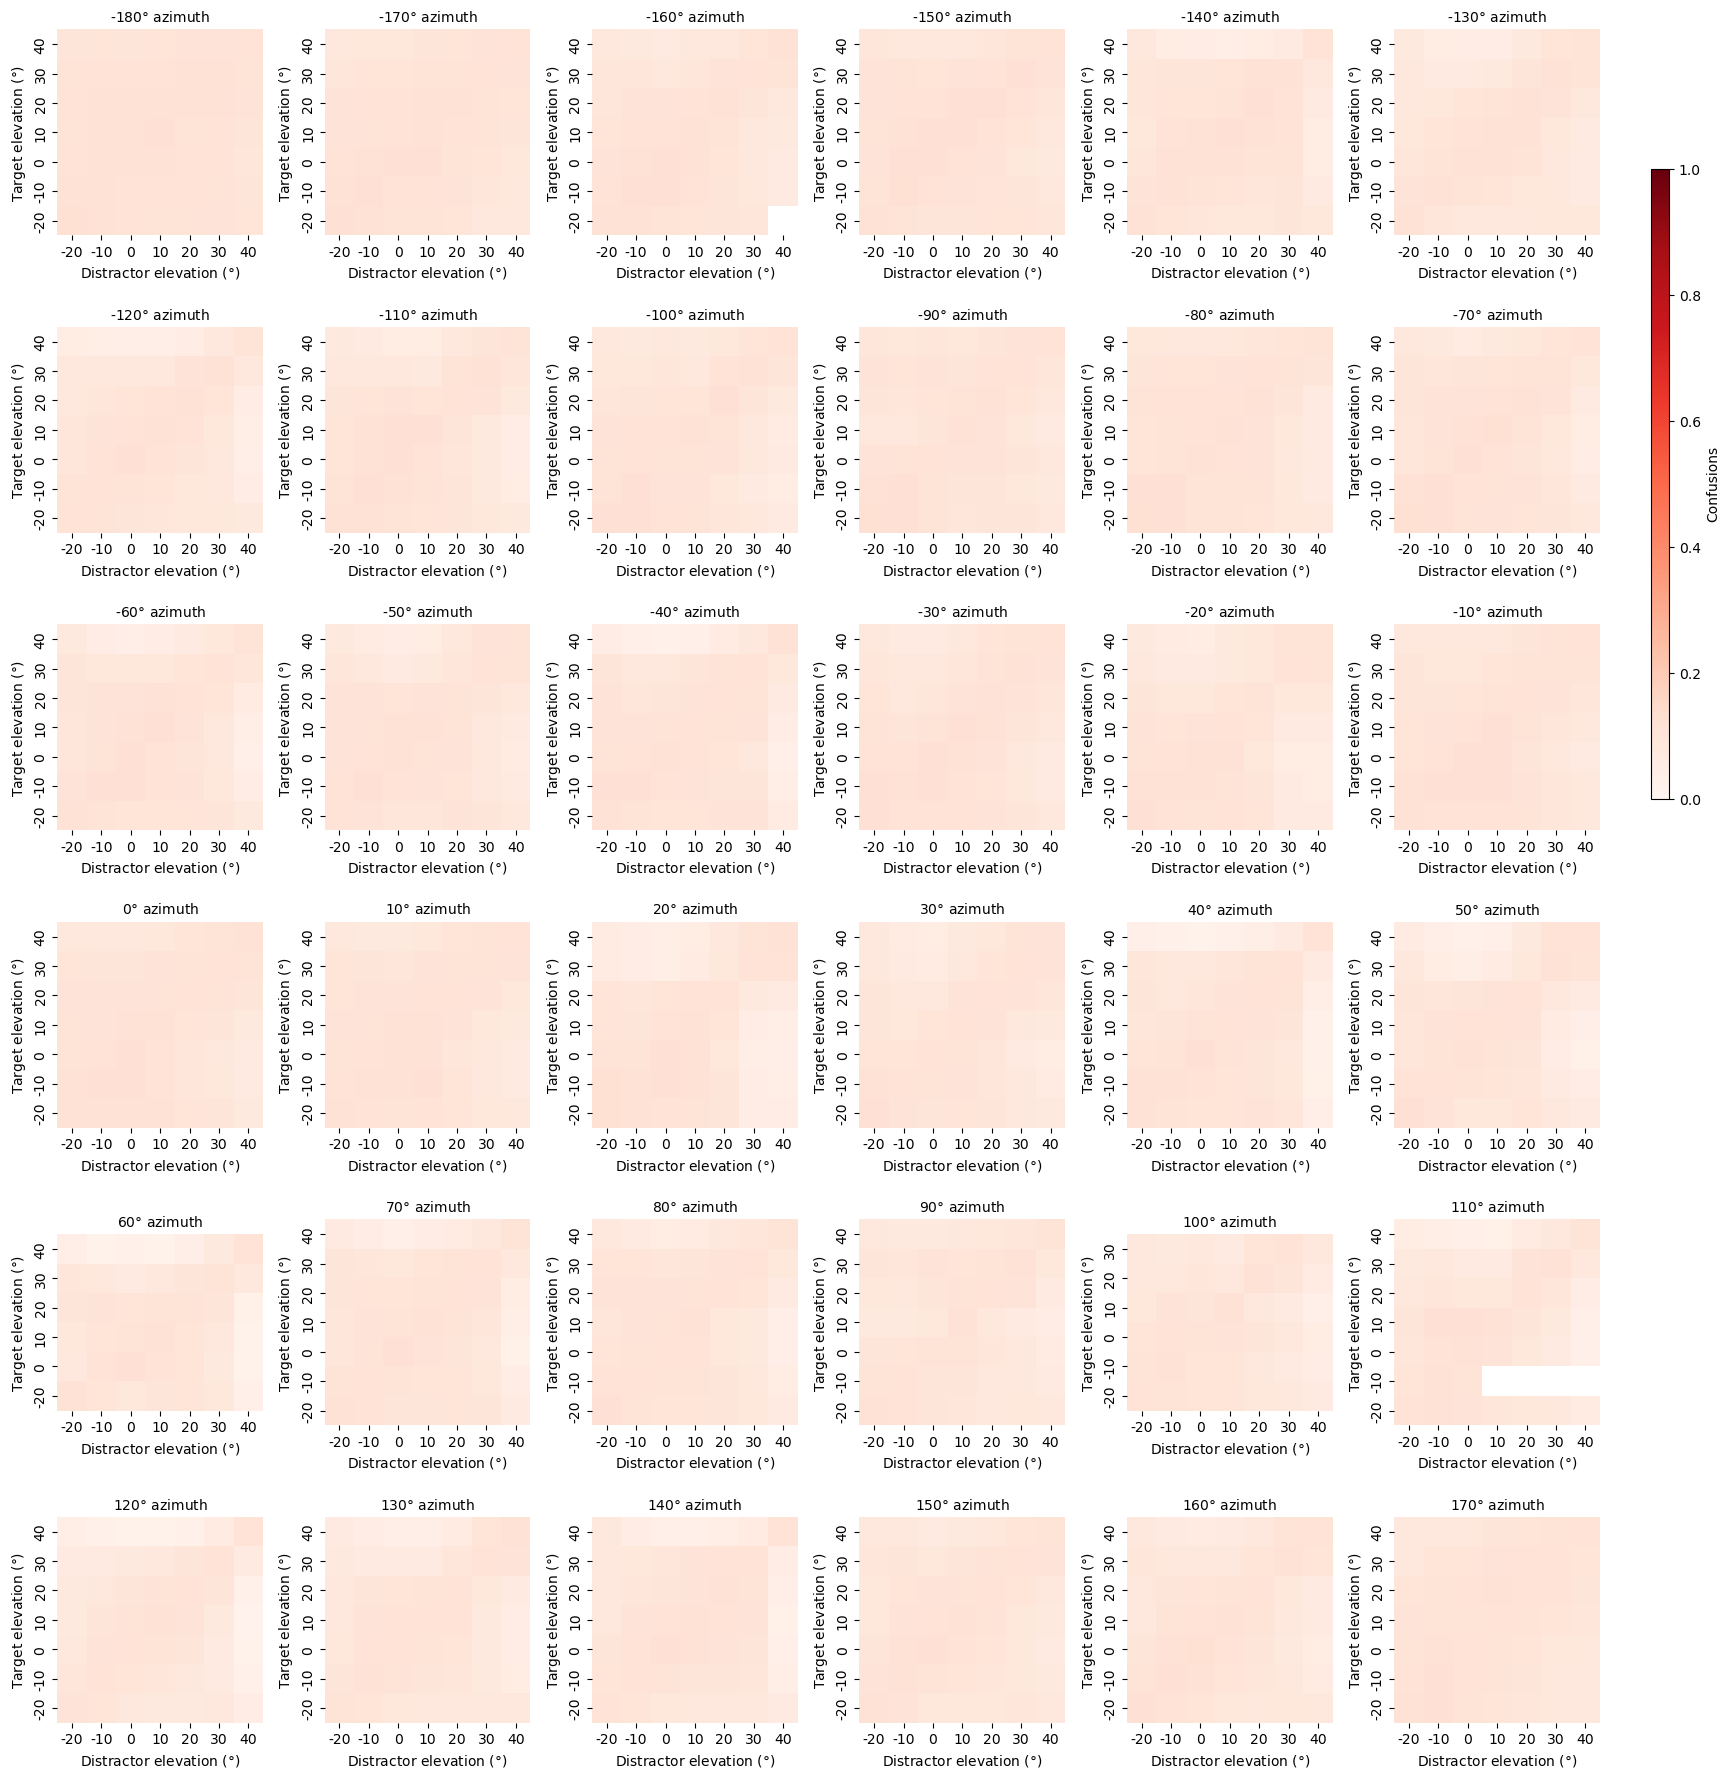

In [ ]:
n_azims = n_unique_azimuths  # number of unique azimuths
n_cols = 6 
n_rows = n_azims // n_cols + (n_azims % n_cols > 0)  # number of rows needed to fit all azimuths

aspect = 3
fontsize = 10

figsize = (n_cols * aspect, n_rows * aspect)
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=False, sharey=False)
axes = axes.flatten()
# Create lists to store the heatmaps for adding colorbars later
conf_heatmaps = []

for i, azim in enumerate(sorted(results.target_azim.unique())):
    # Get performance where sources are co-located in elevation
    azim_df = results[(results.target_azim == azim) & (results.distractor_azim == azim)]

    conf_to_plot = azim_df.groupby(['target_elev', "distractor_elev"])['confusions'].mean().unstack()
    conf_heatmap = sns.heatmap(conf_to_plot, vmin=0, vmax=1, cmap='Reds', cbar=False, ax=axes[i], square=True, robust=True)
    conf_heatmaps.append(conf_heatmap)

    # conf_to_plot = elev_df.groupby(['target_azim', "distractor_azim"])['confusions'].mean().unstack()

    axes[i].set_title(f"{azim}$\degree$ azimuth", fontsize=fontsize)
    

# Add common colorbars for each row
cbar_ax_conf = fig.add_axes([0.92, 0.55, 0.01, 0.35])  # [left, bottom, width, height]

plt.colorbar(conf_heatmaps[0].get_children()[0], cax=cbar_ax_conf, label="Confusions")

for ax in axes.ravel():
    ax.set_xlabel('Distractor elevation ($\degree$)', fontsize=fontsize)
    ax.set_ylabel('Target elevation ($\degree$)', fontsize=fontsize)
    ax.invert_yaxis()
    ax.set_aspect('equal')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbars